In [ ]:
!pip install -Uqq fastbook

In [4]:
!pip install kagglehub

In [29]:
!pip install nbdev

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.1/108.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 18.1 MB/s eta 0:00:00
  Attempting uninstall: fastcore
    Found existing installation: fastcore 1.13.6
    Uninstalling fastcore-1.13.6:
      Successfully uninstalled fastcore-1.13.6


In [30]:
import warnings

warnings.filterwarnings("ignore")

In [31]:
from fastbook import *
from fastai.vision.all import *
from fastai.vision.widgets import *
import os

In [32]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [33]:
import kagglehub

path = kagglehub.dataset_download("hoturam/bear-dataset")

print(path)

Using Colab cache for faster access to the 'bear-dataset' dataset.
/kaggle/input/bear-dataset


In [34]:
os.listdir(path)

['data']

In [35]:
path = os.path.join(path, "data")

In [36]:
os.listdir(path)

['grizzly', 'black', 'polar', 'teddy', 'panda']

In [37]:
path

'/kaggle/input/bear-dataset/data'

In [38]:
for f in os.listdir(path):
    print(f"{f}: {len(os.listdir(os.path.join(path, f)))}")
    # print(os.listdir(os.path.join(path, f)))

grizzly: 46
black: 68
polar: 100
teddy: 50
panda: 45


In [39]:
dls = ImageDataLoaders.from_folder(path,
                                   valid_pct=0.2,
                                   seed=42,
                                   item_tfms=Resize(224))

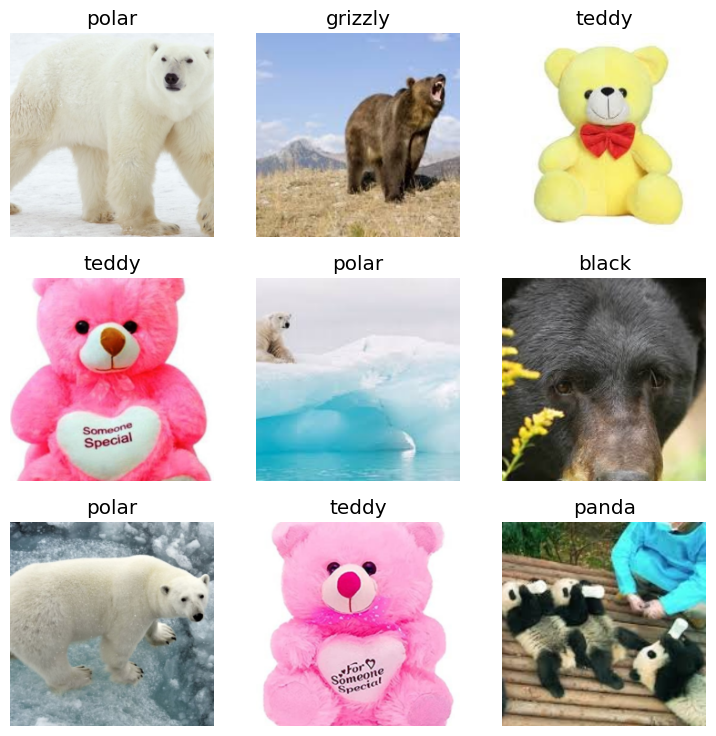

In [40]:
dls.show_batch()

In [41]:
help(verify_images)

Help on function verify_images in module fastai.vision.utils:

verify_images(fns)
    Find images in `fns` that can't be opened



In [42]:
bears = DataBlock(blocks=(ImageBlock, CategoryBlock),
                  get_items=get_image_files,
                  splitter=RandomSplitter(valid_pct=0.2, seed=42),
                  get_y=parent_label,
                  item_tfms=Resize(128))

In [43]:
dls = bears.dataloaders(path)

In [44]:
x, y = dls.one_batch()

In [45]:
print(f"Shape of x: {x.shape}")
print(f"Shape of y: {y.shape}")

Shape of x: torch.Size([64, 3, 128, 128])
Shape of y: torch.Size([64])


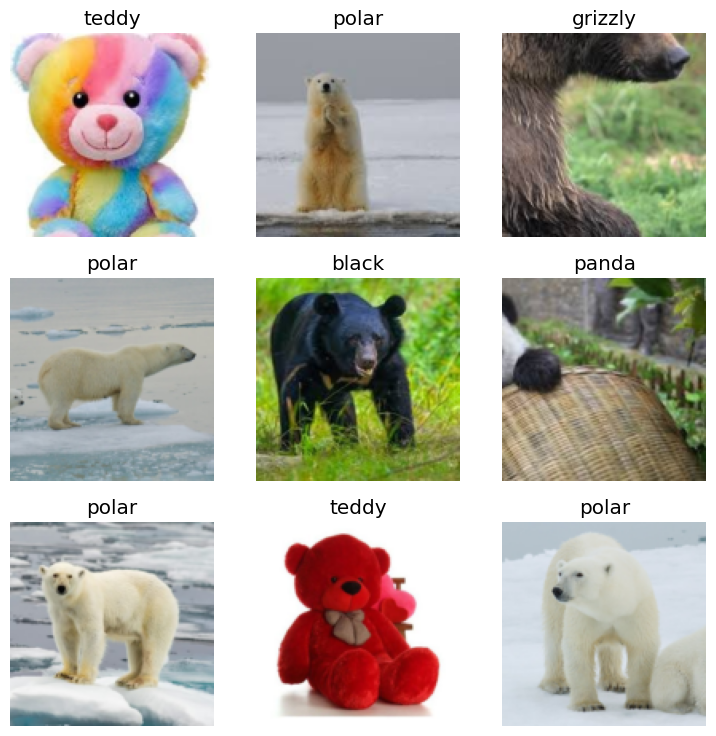

In [46]:
dls.show_batch()

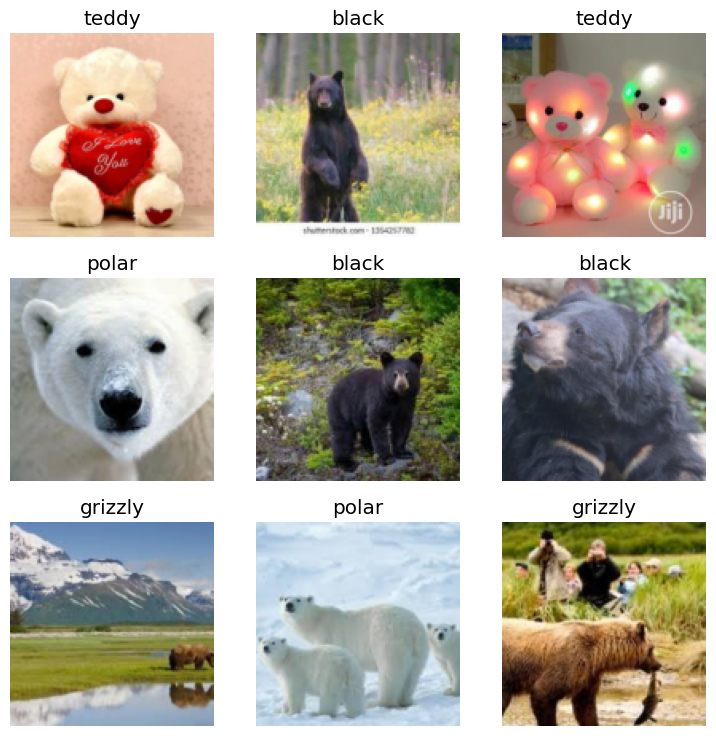

In [47]:
dls.valid.show_batch()

In [50]:
bear = bears.new(item_tfms=RandomResizedCrop(224, min_scale=0.5),
                batch_tfms=aug_transforms())
dls = bears.dataloaders(path)

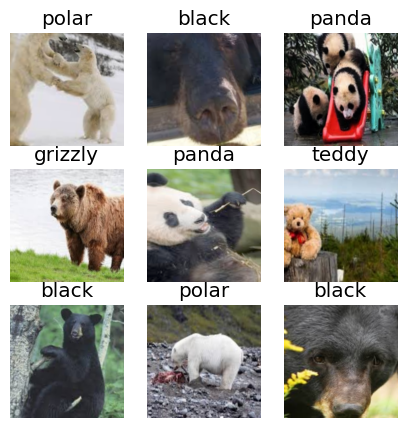

In [52]:
dls.train.show_batch(max_n=9, figsize=(5,5))